# Testing Notebook

# Ignore Trainig and Validation Accuracy, those are not objective truth measruements they are more just a guage to see how far the model is from the actual postion of the car
# Also ignore those metrics for the funciton reportFinalMetrics

In [28]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import config as cfg
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from Data.data_loading import load_and_preprocess_data, create_tensor_from_dataframe, create_sequences, create_dataloaders
from Training.train_matt import Trainer
from Training.basicEval import plotLoss, plotAccuracy, reportFinalMetrics, reportMultiFinalMetrics, plotMultiAccuracy, plotMultiLoss, test_model
from NextNet.model_split import FrameTransformer, print_model_info

from Training.customLoss import ADELoss, FDELoss, RMSELoss, PaddedMSELoss

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
root_dir = os.getcwd()  # Use current working directory as root
data_dir = os.path.join(root_dir, 'Data')
csv_dir = os.path.join(data_dir, 'csv')
csv_file = os.path.join(csv_dir, 'trimmed_IMG_4097_detections.csv')

print("Data directory: ", data_dir)
print("CSV directory: ", csv_dir)
print("CSV file: ", csv_file)


model_dir = os.path.join(root_dir, 'Model')
save_model_dir = os.path.join(model_dir, 'Saved_Model')
print("Model directory: ", model_dir)
print("Saved model directory: ", save_model_dir)


Data directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data
CSV directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv
CSV file:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv\trimmed_IMG_4097_detections.csv
Model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model
Saved model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model


In [29]:
ADE = ADELoss()
FDE = FDELoss()
RMSE = RMSELoss()
customLossMSE = PaddedMSELoss() 

In [30]:
cfg.PREDICTION_LENGTH = 30

df, transformer_max_ids_per_frame, frame_scaler, feature_scaler = load_and_preprocess_data(csv_folder=csv_dir)

# 2. Create tensor from dataframe
all_data_tensor = create_tensor_from_dataframe(df, transformer_max_ids_per_frame)

# 3. Create input-output sequences
X, Y = create_sequences(all_data_tensor)

# 4. Create dataloaders for training and testing
train_loader, test_loader, train_prefetcher, test_prefetcher = create_dataloaders(X, Y)


All CSVs now have 599 frames after trimming
Minimum records per ID: 3
Average records per ID: 1763.55
Maximum records per ID: 3209

Minimum IDs (Vehicles) per frame: 5
Average IDs (Vehicles) per frame: 14.34
Maximum IDs (Vehicles) per frame: 20

Before normalization:
X range: 10.0000 to 1911.0000
Y range: 160.0000 to 1031.0000
Height range: 11.0000 to 442.0000
Width range: 15.0000 to 974.0000
Frame range: 0.0000 to 607.0000

After normalization:
X range: 0.0000 to 5.0000
Y range: 0.0000 to 5.0000
Height range: 0.0000 to 5.0000
Width range: 0.0000 to 5.0000
Frame range: 0.0000 to 5.0000
Determined tensor ID dimension size based on max(ID_Norm): 20
All data tensor shape: torch.Size([6, 599, 20, 5])


# RMSE 1 Second

In [31]:

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 3/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

KeyboardInterrupt: 

Test Loss (MSE): 0.7044
Average Displacement Error (ADE): 0.5486
Root Mean Squared Error (RMSE): 0.7735

Predicted vs Actual (First 5 examples):
Predicted: [[[[ 1.773746    1.7973881 ]
   [ 1.3610277   2.8314    ]
   [ 0.55143666  1.8224105 ]
   ...
   [-1.0840025  -1.0726639 ]
   [-1.0479836  -1.0017772 ]
   [-1.0502436  -1.017973  ]]

  [[ 1.7276514   1.8123475 ]
   [ 1.4210732   2.8564627 ]
   [ 0.60623634  1.9021581 ]
   ...
   [-1.081492   -1.068907  ]
   [-1.0350919  -1.0110271 ]
   [-1.0361571  -1.0180763 ]]

  [[ 1.7892609   1.7782512 ]
   [ 1.4834971   2.8886998 ]
   [ 0.5723914   1.8758528 ]
   ...
   [-1.0744648  -1.0731038 ]
   [-1.0441144  -1.0273907 ]
   [-1.0527096  -1.0311291 ]]

  ...

  [[ 0.9814901   2.5929914 ]
   [ 1.9173441   2.9064198 ]
   [ 1.1433976   2.8405933 ]
   ...
   [-1.0440199  -1.0352786 ]
   [-1.0378559  -1.0316609 ]
   [-1.0325792  -1.0524044 ]]

  [[ 1.012317    2.6271906 ]
   [ 1.9786961   2.9567943 ]
   [ 1.2284274   2.9071643 ]
   ...
   [-1.0616

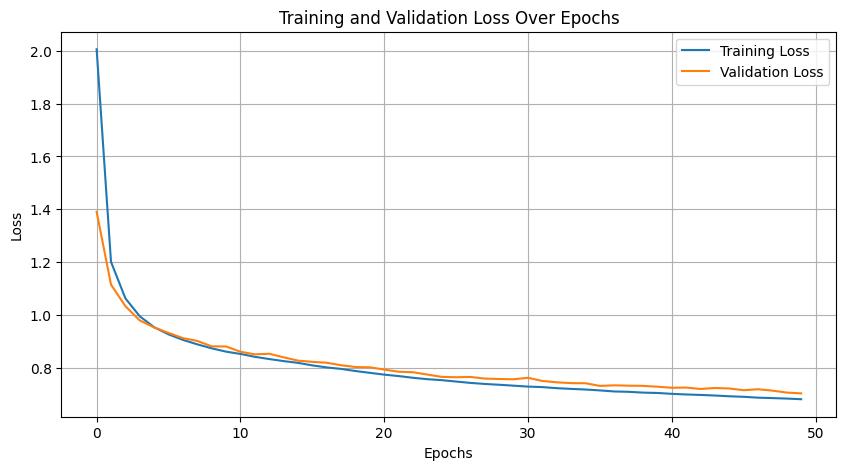

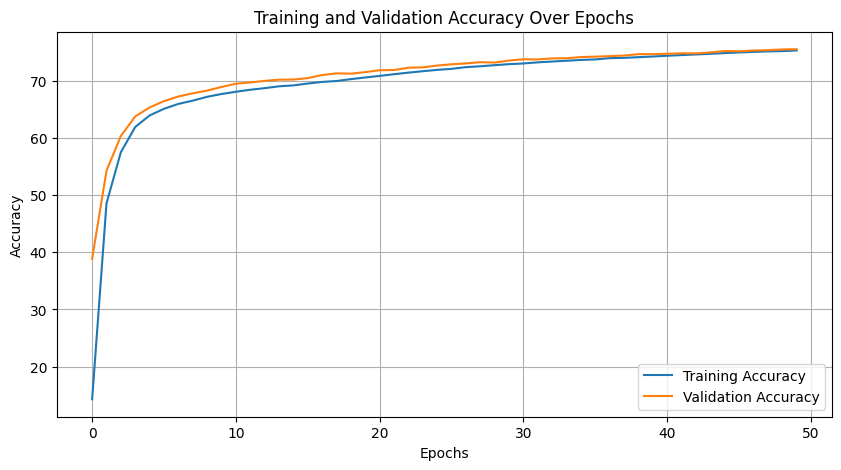

In [ ]:
test_model(model, test_loader,RMSE)

plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)

# RMSE 2 Seconds

In [ ]:
cfg.PREDICTION_LENGTH = 60 # 2 Second
cfg.SEQUENCE_LENGTH = 60 # 2 Second

df, transformer_max_ids_per_frame, frame_scaler, feature_scaler = load_and_preprocess_data(csv_folder=csv_dir)

# 2. Create tensor from dataframe
all_data_tensor = create_tensor_from_dataframe(df, transformer_max_ids_per_frame)

# 3. Create input-output sequences
X, Y = create_sequences(all_data_tensor)

# 4. Create dataloaders for training and testing
train_loader, test_loader, train_prefetcher, test_prefetcher = create_dataloaders(X, Y)

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

test_model(model, test_loader, criterion=RMSE)

plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)


All CSVs now have 599 frames after trimming
Minimum records per ID: 3
Average records per ID: 1763.55
Maximum records per ID: 3209

Minimum IDs (Vehicles) per frame: 5
Average IDs (Vehicles) per frame: 14.34
Maximum IDs (Vehicles) per frame: 20

Before normalization:
X range: 10.0000 to 1911.0000
Y range: 160.0000 to 1031.0000
Height range: 11.0000 to 442.0000
Width range: 15.0000 to 974.0000
Frame range: 0.0000 to 607.0000

After normalization:
X range: 0.0000 to 5.0000
Y range: 0.0000 to 5.0000
Height range: 0.0000 to 5.0000
Width range: 0.0000 to 5.0000
Frame range: 0.0000 to 5.0000


ValueError: too many values to unpack (expected 3)

# RMSE 3 Seconds


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 254.01 seconds, or 4.23 minutes
Total epochs run: 50
Average time per epoch: 5.08 seconds
Inference time per batch: 0.07 seconds
Final Training Loss: 0.6736
Final Validation Loss: 0.7027
Final Training Accuracy: 90.80%
Final Validation Accuracy: 90.98%


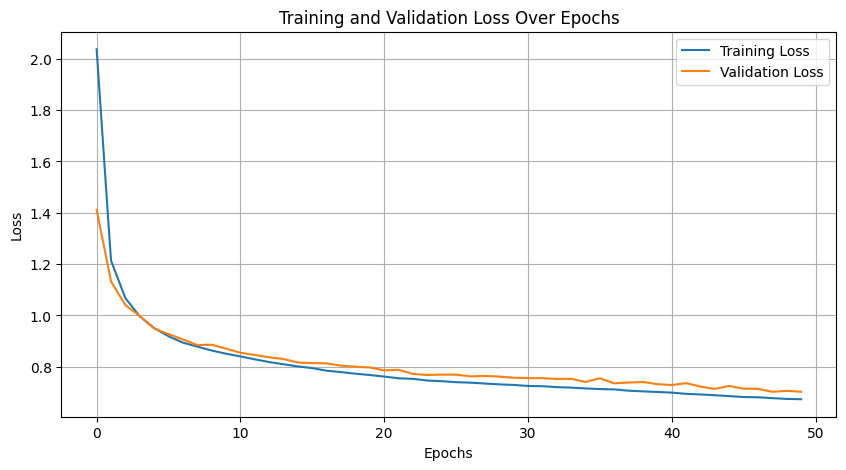

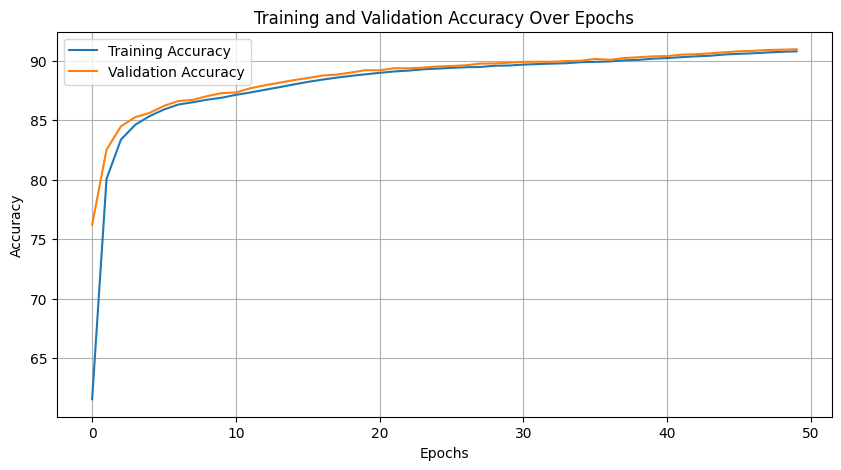

Final Training Accuracy: 0.67%
Final Validation Accuracy: 0.70%
Final Training Loss: 90.8047
Final Validation Loss: 90.9832
Total Training Time: 253.97 seconds


In [ ]:
cfg.PREDICTION_LENGTH = 30 # 3 Second
cfg.SEQUENCE_LENGTH = 90 # 3 Second

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

test_model(model, test_loader, criterion=RMSE)


plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)

# RMSE 4 Seconds


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 247.29 seconds, or 4.12 minutes
Total epochs run: 50
Average time per epoch: 4.95 seconds
Inference time per batch: 0.07 seconds
Final Training Loss: 0.6851
Final Validation Loss: 0.7118
Final Training Accuracy: 90.48%
Final Validation Accuracy: 90.65%


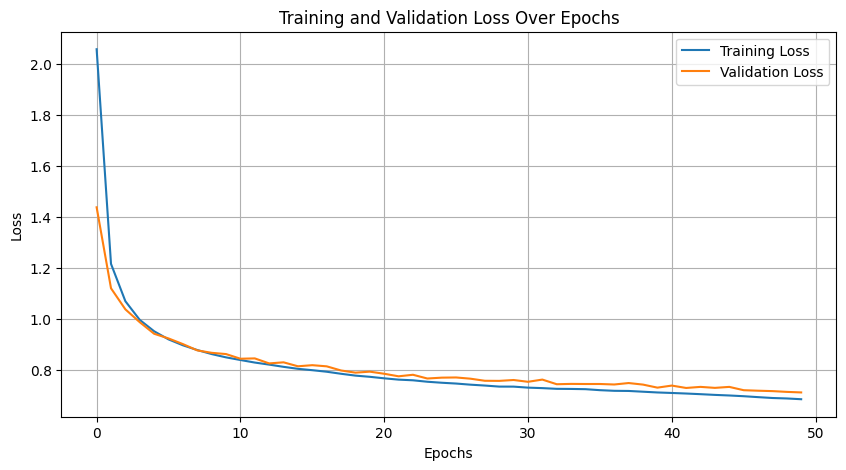

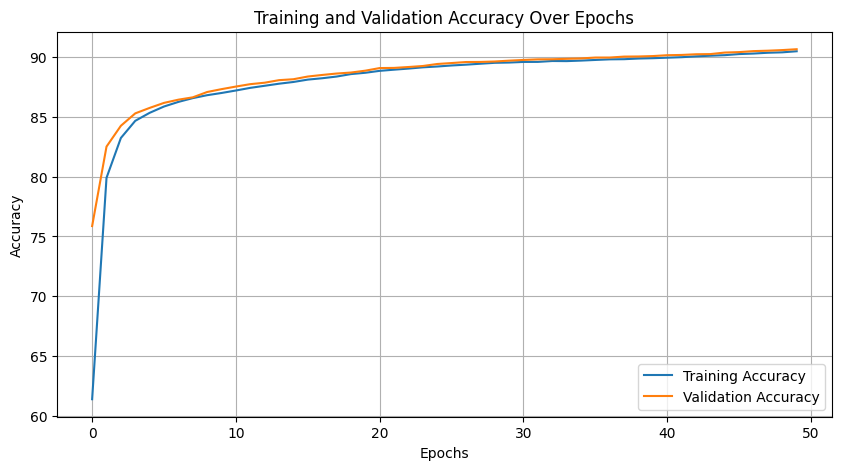

Final Training Accuracy: 0.69%
Final Validation Accuracy: 0.71%
Final Training Loss: 90.4843
Final Validation Loss: 90.6538
Total Training Time: 247.27 seconds


In [ ]:
cfg.PREDICTION_LENGTH = 30 # 4 Second
cfg.SEQUENCE_LENGTH = 120 # 4 Second

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

test_model(model, test_loader, criterion=RMSE)

plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)